<a href="https://colab.research.google.com/github/aqilfiras/SMS-Classification/blob/main/SMS_Spam_CLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 34.3 MB/s eta 0:00:00


In [7]:
import torch
import gensim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Change device to 'cuda' if available

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get the data

In [9]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
data = data.rename(columns={'v1': 'label', 'v2': 'text'})
print(data['label'].value_counts())
data = data.replace({'ham': 0, 'spam': 1})
data.head()

label
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipykernel_2000/1875481415.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'ham': 0, 'spam': 1})


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Set values for x and y

In [10]:
y_raw,X_raw = data['label'].copy().tolist(), data['text'].copy().str.lower().tolist()

In [11]:
X_raw

['go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...',
 'ok lar... joking wif u oni...',
 "free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's",
 'u dun say so early hor... u c already then say...',
 "nah i don't think he goes to usf, he lives around here though",
 "freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send, å£1.50 to rcv",
 'even my brother is not like to speak with me. they treat me like aids patent.',
 "as per your request 'melle melle (oru minnaminunginte nurungu vettam)' has been set as your callertune for all callers. press *9 to copy your friends callertune",
 'winner!! as a valued network customer you have been selected to receivea å£900 prize reward! to claim call 09061701461. claim code kl341. valid 12 hours only.',
 'had y

# Select and load model

In [ ]:
model = SentenceTransformer('sentence-transformers/all-roberta-large-v1', device = 'cuda')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

# Convert the mails into embeddings

In [ ]:
sentence_embeddings = model.encode(X_raw, convert_to_tensor=True )

In [ ]:
sentence_embeddings

tensor([[ 0.0004,  0.0169,  0.0090,  ...,  0.0257,  0.0165, -0.0299],
        [ 0.0037,  0.0498,  0.0152,  ...,  0.0188, -0.0259, -0.0429],
        [-0.0025, -0.0355,  0.0256,  ...,  0.0809, -0.0336,  0.0126],
        ...,
        [ 0.0263, -0.0046, -0.0156,  ...,  0.0627, -0.0235, -0.0227],
        [ 0.0045,  0.0293,  0.0244,  ...,  0.0197,  0.0455, -0.0101],
        [ 0.0071,  0.0049,  0.0175,  ...,  0.0631, -0.0488, -0.0221]],
       device='cuda:0')

# Split into training and test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sentence_embeddings, y_raw, test_size=0.2, random_state=42)


# Load and perform standard scaling on the training and test set

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.cpu())
X_test = scaler.transform(X_test.cpu())

# Convert into pytorch tensors

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device = device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device = device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device = device).unsqueeze(1)

In [ ]:
X_train_tensor.shape

torch.Size([4457, 1024])

# Build the logistic regression class

In [ ]:
class LogisticRegression(nn.Module):
  def __init__(self, input_dim):
    super(LogisticRegression, self).__init__()
    self.hidden = nn.Linear(input_dim, 16)
    self.relu = nn.ReLU()
    self.output = nn.Linear(16, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.hidden(x)
    x = self.relu(x)
    x = self.output(x)
    return x

# Load the model, criterion, and optimizer

In [ ]:
model = LogisticRegression(input_dim=1024).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training session

In [ ]:
epochs = 100
for epoch in range(epochs):
  optimizer.zero_grad()
  logits = model(X_train_tensor)
  loss = criterion(logits, y_train_tensor)
  loss.backward()
  optimizer.step()
  if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.2847
Epoch [20/100], Loss: 0.1531
Epoch [30/100], Loss: 0.0937
Epoch [40/100], Loss: 0.0638
Epoch [50/100], Loss: 0.0466
Epoch [60/100], Loss: 0.0360
Epoch [70/100], Loss: 0.0290
Epoch [80/100], Loss: 0.0239
Epoch [90/100], Loss: 0.0200
Epoch [100/100], Loss: 0.0169


# Evaluate model on the test set

In [ ]:
model.eval()
with torch.no_grad():
    raw_logits = model(X_test_tensor)

    probabilities = torch.sigmoid(raw_logits)

    predictions = (probabilities >= 0.5).int()

In [ ]:
predictions

tensor([[0],
        [0],
        [1],
        ...,
        [0],
        [0],
        [1]], device='cuda:0', dtype=torch.int32)

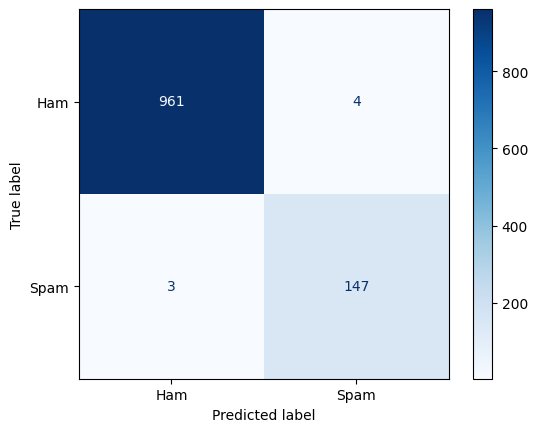

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_tensor.cpu(),
    predictions.cpu(),
    display_labels=['Ham', 'Spam'],
    cmap=plt.cm.Blues
)

plt.show()
print(classification_report(y_test_tensor.cpu(),predictions.cpu()))